In [55]:
import fastf1
import fastf1.plotting  # ← この行を追加します
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# キャッシュの有効化とプロットの初期設定
fastf1.Cache.enable_cache('cache')
fastf1.plotting.setup_mpl()  # ← カッコの中身は空にします

In [56]:
# =========================================================
# 1. スプリント予選 (Sprint Shootout / SQ) のデータ抽出
# =========================================================
session_sq = fastf1.get_session(2026, 'China', 'SQ')
session_sq.load()

# クイックラップを抽出し、LapTimeが空欄(NaN)のデータを除外
valid_laps = session_sq.laps.pick_quicklaps().dropna(subset=['LapTime'])

# ドライバーごとにLapTimeが最小（最速）の行のインデックスを取得して絞り込む
idx = valid_laps.groupby('Driver')['LapTime'].idxmin()
sq_laps = valid_laps.loc[idx].copy()

# =========================================================
# 【追加】テレメトリーからそのラップ中の「真の最高速」を取得
# =========================================================
max_speeds = []
# iterlaps() は (インデックス, ラップデータ) のペアを返すため、_, lap で受け取ります
for _, lap in sq_laps.iterlaps():
    # そのラップのテレメトリー（車載データ）を読み込む
    car_data = lap.get_car_data()
    # テレメトリー内の 'Speed' (速度) の最大値をリストに追加
    if not car_data.empty:
        max_speeds.append(car_data['Speed'].max())
    else:
        max_speeds.append(np.nan)

# 新しいカラムとして追加
sq_laps['MaxSpeed'] = max_speeds

# 必要なカラムを抽出（'MaxSpeed' を追加）
sq_summary = sq_laps[['Driver', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedST', 'SpeedFL', 'MaxSpeed']].dropna()

# タイム順にソート
sq_summary = sq_summary.sort_values('LapTime').reset_index(drop=True)

print("【スプリント予選：主要データ】")
print(sq_summary.head(10)) # トップ10を表示

core           INFO 	Loading data for Chinese Grand Prix - Sprint Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	Sprint Qualifying is not supported by Ergast! Limited results are calculated from timing data.
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 11
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 11)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core         

【スプリント予選：主要データ】
  Driver                LapTime            Sector1Time            Sector2Time  \
0    RUS 0 days 00:01:31.520000 0 days 00:00:23.962000 0 days 00:00:27.569000   
1    ANT 0 days 00:01:31.809000 0 days 00:00:23.998000 0 days 00:00:27.598000   
2    NOR 0 days 00:01:32.141000 0 days 00:00:23.961000 0 days 00:00:27.616000   
3    HAM 0 days 00:01:32.161000 0 days 00:00:24.110000 0 days 00:00:27.694000   
4    PIA 0 days 00:01:32.224000 0 days 00:00:23.913000 0 days 00:00:27.793000   
5    LEC 0 days 00:01:32.528000 0 days 00:00:24.105000 0 days 00:00:27.770000   
6    GAS 0 days 00:01:32.888000 0 days 00:00:24.293000 0 days 00:00:27.840000   
7    VER 0 days 00:01:33.254000 0 days 00:00:24.404000 0 days 00:00:28.258000   
8    BEA 0 days 00:01:33.409000 0 days 00:00:24.401000 0 days 00:00:28.079000   
9    HAD 0 days 00:01:33.620000 0 days 00:00:24.650000 0 days 00:00:28.477000   

             Sector3Time  SpeedST  SpeedFL  MaxSpeed  
0 0 days 00:00:39.989000    313.0    

/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_dr

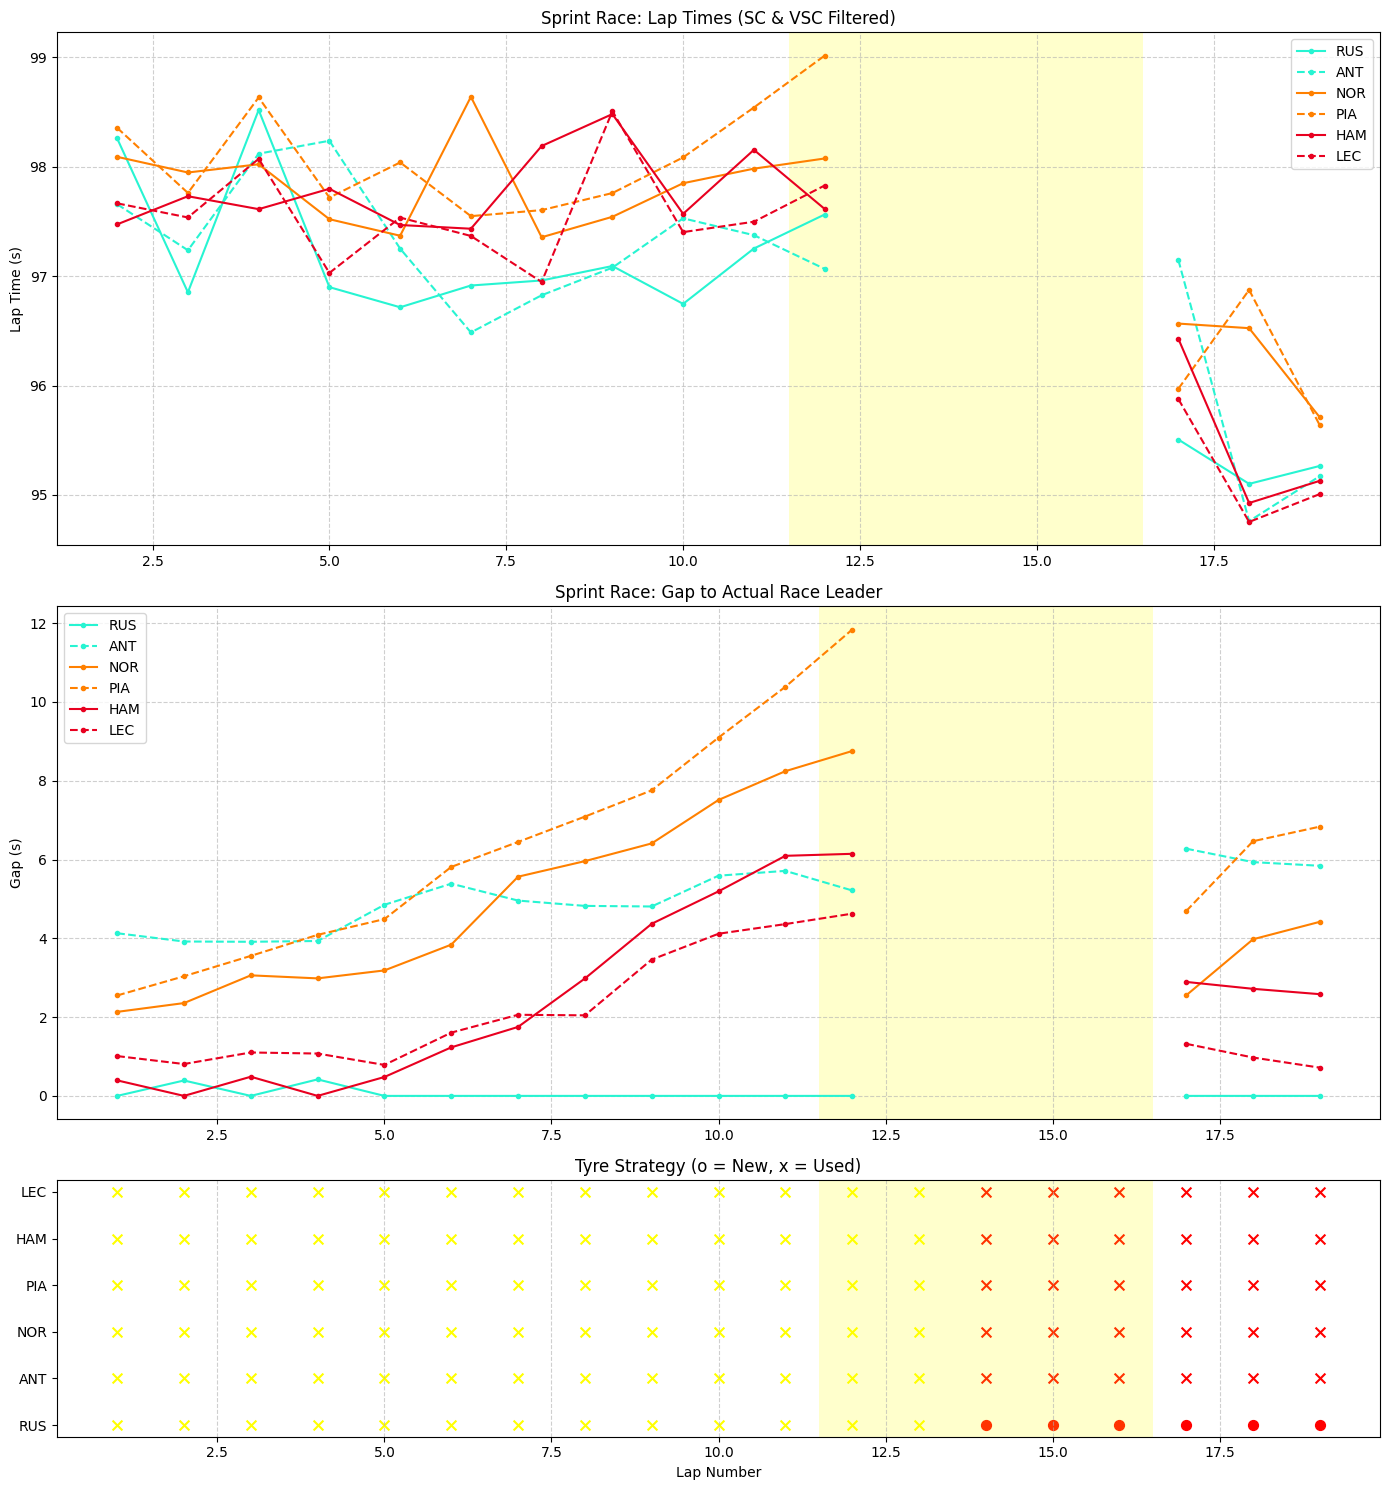

In [57]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15), gridspec_kw={'height_ratios': [2, 2, 1]})

# =========================================================
# 【追加】SC/VSCが発生したラップを特定し、背景を黄色に塗る関数
# =========================================================
# TrackStatusに4, 6, 7が含まれるラップ番号の重複のないリストを作成
sc_vsc_laps = laps_s[laps_s['TrackStatus'].astype(str).str.contains('4|6|7')]['LapNumber'].unique()

def add_sc_vsc_shading(ax):
    for lap in sc_vsc_laps:
        # 該当ラップの前後0.5周分を黄色(yellow)で半透明(alpha=0.2)に塗る
        ax.axvspan(lap - 0.5, lap + 0.5, color='yellow', alpha=0.2, lw=0)

# =========================================================
# 色かぶり対策：ドライバーごとの線のスタイルを事前決定
# =========================================================
driver_styles = {}
color_counts = {}

for drv in drivers:
    color = fastf1.plotting.get_driver_color(drv, session_s)
    if color not in color_counts:
        color_counts[color] = 0
    color_counts[color] += 1
    
    if color_counts[color] == 1:
        ls = '-'
    elif color_counts[color] == 2:
        ls = '--'
    else:
        ls = ':'
        
    driver_styles[drv] = {'color': color, 'linestyle': ls}

# =========================================================
# ① ラップタイムの推移
# =========================================================
for drv in drivers:
    drv_laps = laps_s.pick_driver(drv)
    color = driver_styles[drv]['color']
    ls = driver_styles[drv]['linestyle']
    
    axes[0].plot(drv_laps['LapNumber'], drv_laps['CleanLapTime'], 
                 label=drv, color=color, linestyle=ls, marker='.')

axes[0].set_title('Sprint Race: Lap Times (SC & VSC Filtered)')
axes[0].set_ylabel('Lap Time (s)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)
add_sc_vsc_shading(axes[0]) # 背景を黄色に

# =========================================================
# ② 実際のラップリーダー（その周のトップ）とのギャップ推移
# =========================================================
actual_leader_laps = laps_s.groupby('LapNumber')['Time'].min().reset_index()
actual_leader_laps.rename(columns={'Time': 'LeaderTime'}, inplace=True)

for drv in drivers:
    # TrackStatusも判定用に抽出しておく
    drv_laps = laps_s.pick_driver(drv)[['LapNumber', 'Time', 'TrackStatus']]
    color = driver_styles[drv]['color']
    ls = driver_styles[drv]['linestyle']
    
    merged = pd.merge(drv_laps, actual_leader_laps, on='LapNumber')
    
    # ギャップ（秒）を計算
    merged['Gap'] = (merged['Time'] - merged['LeaderTime']).dt.total_seconds()
    
    # 【追加】SC/VSC中のラップはギャップをNaNにして線を切断する
    mask_sc_vsc = merged['TrackStatus'].astype(str).str.contains('4|6|7')
    merged.loc[mask_sc_vsc, 'Gap'] = np.nan
    
    axes[1].plot(merged['LapNumber'], merged['Gap'], 
                 label=drv, color=color, linestyle=ls, marker='.')

axes[1].set_title('Sprint Race: Gap to Actual Race Leader')
axes[1].set_ylabel('Gap (s)')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)
add_sc_vsc_shading(axes[1]) # 背景を黄色に

# =========================================================
# ③ タイヤの使用履歴・スティント
# =========================================================
compound_colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'white', 'INTERMEDIATE': 'green', 'WET': 'blue'}

for i, drv in enumerate(drivers):
    drv_laps = laps_s.pick_driver(drv)
    
    for _, lap in drv_laps.iterrows():
        comp = str(lap['Compound'])
        color = compound_colors.get(comp, 'grey')
        is_new = lap['FreshTyre'] == True
        marker = 'o' if is_new else 'x'
        
        axes[2].scatter(lap['LapNumber'], i, color=color, marker=marker, s=50)

axes[2].set_title('Tyre Strategy (o = New, x = Used)')
axes[2].set_yticks(range(len(drivers)))
axes[2].set_yticklabels(drivers)
axes[2].set_xlabel('Lap Number')
axes[2].grid(True, axis='x', linestyle='--', alpha=0.6)
add_sc_vsc_shading(axes[2]) # 背景を黄色に

plt.tight_layout()
plt.show()

In [58]:
# =========================================================
# 3. タイヤの詳細情報 (使用周回数・スティント分析)
# =========================================================
stints = laps_s.groupby(['Driver', 'Stint']).agg({
    'Compound': 'first',
    'FreshTyre': 'first',
    'TyreLife': ['min', 'max'], # Stint内の最小周回数(Start_Age)と最大周回数(End_Age)
    'CleanLapTime': 'mean'      # 【追加】SC/VSCを除外したクリーンな平均ラップタイム(秒)
}).reset_index()

# カラム名に平均タイムを追加
stints.columns = ['Driver', 'Stint', 'Compound', 'Is_New', 'Start_Age', 'End_Age', 'Avg_Clean_Lap(s)']

# 見やすいように小数点以下3桁に丸める
stints['Avg_Clean_Lap(s)'] = stints['Avg_Clean_Lap(s)'].round(3)

print("\n【タイヤ使用履歴と平均ペース詳細】")
print(stints[stints['Driver'].isin(drivers)])


【タイヤ使用履歴と平均ペース詳細】
   Driver  Stint Compound  Is_New  Start_Age  End_Age  Avg_Clean_Lap(s)
3     ANT    1.0   MEDIUM   False        4.0     16.0            97.350
4     ANT    2.0     SOFT   False        6.0     11.0            95.693
13    HAM    1.0   MEDIUM   False        6.0     18.0            97.775
14    HAM    2.0     SOFT   False        6.0     11.0            95.494
17    LEC    1.0   MEDIUM   False        5.0     17.0            97.580
18    LEC    2.0     SOFT   False        6.0     11.0            95.212
20    NOR    1.0   MEDIUM   False        5.0     17.0            97.854
21    NOR    2.0     SOFT   False        4.0      9.0            96.266
25    PIA    1.0   MEDIUM   False        5.0     17.0            98.096
26    PIA    2.0     SOFT   False        4.0      9.0            96.160
27    RUS    1.0   MEDIUM   False        4.0     16.0            97.252
28    RUS    2.0     SOFT    True        1.0      6.0            95.291


### スロットル比較

抽出区間: Turn 13 (3419.9m) 〜 Turn 14 (4811.1m)


/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/kazuma/F1_NEW_Analysis_/.venv/lib/python3.10/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_dr

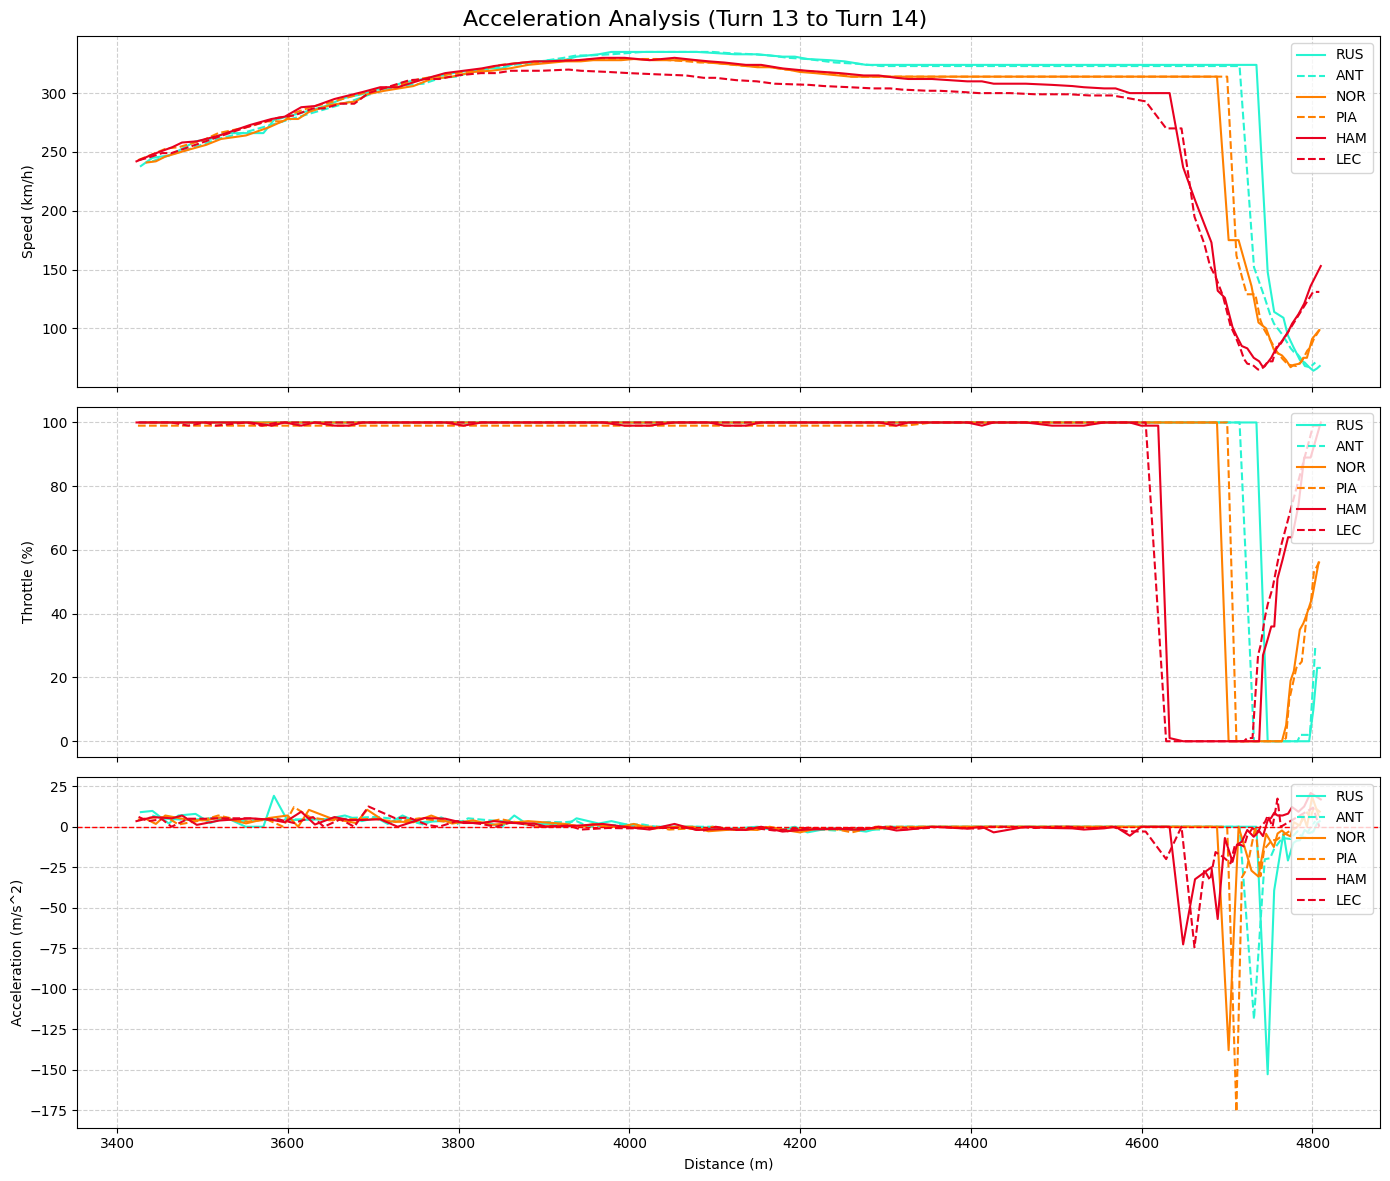

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import fastf1.plotting

# =========================================================
# 分析対象のドライバー設定
# =========================================================
# 先ほどのRUSに加え、ご指定のドライバーを追加
drivers = ['RUS', 'ANT', 'NOR', 'PIA', 'HAM', 'LEC']

# =========================================================
# サーキット情報から特定のコーナー区間を自動抽出
# =========================================================
circuit_info = session_sq.get_circuit_info()
t13_dist = circuit_info.corners.loc[circuit_info.corners['Number'] == 13, 'Distance'].values[0]
t14_dist = circuit_info.corners.loc[circuit_info.corners['Number'] == 14, 'Distance'].values[0]

print(f"抽出区間: Turn 13 ({t13_dist:.1f}m) 〜 Turn 14 ({t14_dist:.1f}m)")

# =========================================================
# 色かぶり対策：ドライバーごとの線のスタイルを事前決定
# =========================================================
driver_styles = {}
color_counts = {}

for drv in drivers:
    color = fastf1.plotting.get_driver_color(drv, session_sq)
    if color not in color_counts:
        color_counts[color] = 0
    color_counts[color] += 1
    
    # 1人目は実線、2人目（チームメイト）は破線
    if color_counts[color] == 1:
        ls = '-'
    else:
        ls = '--'
        
    driver_styles[drv] = {'color': color, 'linestyle': ls}

# =========================================================
# グラフの初期設定
# =========================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# =========================================================
# 各ドライバーのデータをループ処理で取得・計算・描画
# =========================================================
for drv in drivers:
    # 対象ドライバーの最速ラップデータを抽出
    lap = sq_laps.pick_driver(drv).iloc[0]
    
    # テレメトリーデータ（距離付き）を取得
    tel = lap.get_car_data().add_distance()
    
    # 時間を秒に、速度をm/sに変換
    tel['Time_sec'] = tel['Time'].dt.total_seconds()
    tel['Speed_ms'] = tel['Speed'] / 3.6
    
    # 【追加反映】スロットルの上限を100に強制カット
    tel['Throttle'] = tel['Throttle'].clip(upper=100)
    
    # 加速度 (m/s^2) の算出
    tel['Acceleration'] = tel['Speed_ms'].diff() / tel['Time_sec'].diff().replace(0, np.nan)
    
    # ターン13〜ターン14の距離でフィルタリング
    mask_dist = (tel['Distance'] >= t13_dist) & (tel['Distance'] <= t14_dist)
    tel_straight = tel[mask_dist]
    
    # 割り当てられた色と線のスタイルを取得
    color = driver_styles[drv]['color']
    ls = driver_styles[drv]['linestyle']
    
    # グラフへのプロット
    axes[0].plot(tel_straight['Distance'], tel_straight['Speed'], 
                 color=color, linestyle=ls, label=drv)
    
    axes[1].plot(tel_straight['Distance'], tel_straight['Throttle'], 
                 color=color, linestyle=ls, label=drv)
    
    axes[2].plot(tel_straight['Distance'], tel_straight['Acceleration'], 
                 color=color, linestyle=ls, label=drv)

# =========================================================
# グラフの装飾・体裁を整える
# =========================================================
axes[0].set_ylabel('Speed (km/h)')
axes[0].legend(loc='upper right') # ← ここを 'lower right' から 'upper right' に変更
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].set_ylabel('Throttle (%)')
axes[1].legend(loc='upper right') # ← ここも 'lower right' から 'upper right' に変更
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].axhline(0, color='red', linestyle='--', linewidth=1) 
axes[2].set_xlabel('Distance (m)')
axes[2].set_ylabel('Acceleration (m/s^2)')
axes[2].legend(loc='upper right') # ← ここは元から 'upper right' ならそのままでOK
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Acceleration Analysis (Turn 13 to Turn 14)", fontsize=16)
plt.tight_layout()
plt.show()